Ollama test

In [2]:
from ollama import chat
from ollama import ChatResponse

response: ChatResponse = chat(model='gemma3:4b', messages=[
  {
    'role': 'user',
    'content': 'Why is the sky blue?',
  },
])
print(response['message']['content'])
# or access fields directly from the response object
print(response.message.content)

The blue color of the sky is a fascinating phenomenon caused by a process called **Rayleigh scattering**. Here's a breakdown of how it works:

**1. Sunlight and its Colors:**

* Sunlight isn't just white light. It's actually made up of *all* the colors of the rainbow – red, orange, yellow, green, blue, indigo, and violet. Think of a prism splitting sunlight.

**2. What is Rayleigh Scattering?**

* **Waves and Scattering:** Light travels in waves.  When these light waves encounter tiny particles in the atmosphere (like nitrogen and oxygen molecules), they get bounced around – this is scattering.
* **Shorter Wavelengths Scatter More:** Rayleigh scattering is *most effective* when dealing with shorter wavelengths of light. Blue and violet light have the shortest wavelengths in the visible spectrum.

**3. Why Blue Specifically?**

* **Blue Light Gets Scattered Everywhere:** Because blue light has the shortest wavelength, it's scattered much more strongly than other colors.  The atmospheric

Sentiment generation

In [3]:
import pandas as pd
import ollama
import ast
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np

print("Cell 1/7: Libraries imported.")

Cell 1/7: Libraries imported.


In [ ]:
# %%
# ## 2. Configure and Test Ollama Client
# This cell connects to your local Ollama instance.

try:
    client = ollama.Client()
    client.list() # Test the connection
    print("Successfully connected to local Ollama instance.")
except Exception as e:
    print("--- CONNECTION FAILED ---")
    print("Could not connect to Ollama. Please ensure the Ollama application is running on your Mac.")
    print(f"Error details: {e}")
    # We exit here if we can't connect so the script doesn't continue with an error
    exit()


Successfully connected to local Ollama instance.


In [ ]:
# %%
# ## 3. Load and Prepare the Dataset
# This cell loads your BTC.csv file.

try:
    df = pd.read_csv('BTC.csv')
    df['date'] = pd.to_datetime(df['begins_at']).dt.date
    print("Dataset 'BTC.csv' loaded successfully.")
except FileNotFoundError:
    print("--- FILE NOT FOUND ---")
    print("Error: 'BTC.csv' not found. Make sure it is in the same folder as this script.")
    exit()

# Parse the articles column from a string to a list
df['articles'] = df['articles'].apply(ast.literal_eval)

# Explode the DataFrame to have one row per article
articles_df = df.explode('articles').rename(columns={'articles': 'headline'})
articles_df = articles_df[articles_df['headline'].apply(isinstance, args=(str,))].copy()



print(f"Dataset prepared. Analyzing all {len(articles_df)} headlines.")


Dataset 'BTC.csv' loaded successfully.
Dataset prepared. Analyzing all 17964 headlines.


In [6]:
# %%
# ## 4. Define the Ollama Sentiment Analysis Function
# This cell defines the function that will send each headline to the local model.

def get_ollama_sentiment(headline):
    """
    Sends a headline to the local Ollama model and returns a sentiment score.
    Returns a score from -1 (Negative) to 1 (Positive).
    """
    try:
        response = client.chat(
            model='gemma3:4b',
            messages=[
                {
                    'role': 'user',
                    'content': f"""Analyze the sentiment of the following financial news headline.
Classify it as 'Positive', 'Negative', or 'Neutral'.
Return only one word for the classification.

Headline: "{headline}"
Sentiment:""",
                },
            ]
        )
        sentiment = response['message']['content'].strip().lower()

        if 'positive' in sentiment:
            return 1.0
        elif 'negative' in sentiment:
            return -1.0
        else: # Neutral or any other response
            return 0.0
            
    except Exception as e:
        print(f"Ollama Error for headline '{headline}': {e}")
        return 0.0

print("Cell 4/7: Sentiment analysis function defined.")


Cell 4/7: Sentiment analysis function defined.


In [ ]:
# %%
# ## 5. Perform Sentiment Analysis
# This is the main processing step. It will loop through all headlines and get the sentiment.

# Link tqdm with pandas for a progress bar
tqdm.pandas(desc="Analyzing Headlines with Ollama")

# Apply the function to each headline
articles_df['sentiment_score_ollama'] = articles_df['headline'].progress_apply(get_ollama_sentiment)

print("\nSentiment analysis complete.")


Analyzing Headlines with Ollama: 100%|██████████| 17964/17964 [1:27:57<00:00,  3.40it/s]


Sentiment analysis complete.


In [10]:
# %%
# ## 6. Aggregate Scores and Save Results
# This cell calculates the average daily sentiment and saves the final data to a new CSV file.

print("Aggregating scores and saving CSV...")

# Aggregate scores by day
daily_sentiment = articles_df.groupby('date')['sentiment_score_ollama'].mean().reset_index()
df['date'] = pd.to_datetime(df['date'])
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])
final_df = pd.merge(df, daily_sentiment, on='date', how='left')

# Save the results to a CSV file
output_filename = 'BTC_with_Ollama_sentiment.csv'
final_df.to_csv(output_filename, index=False)
print(f"Results saved to '{output_filename}'")

Aggregating scores and saving CSV...
Results saved to 'BTC_with_Ollama_sentiment.csv'


Generating visualization...
Chart saved to 'BTC_Price_vs_Ollama_Sentiment.png'


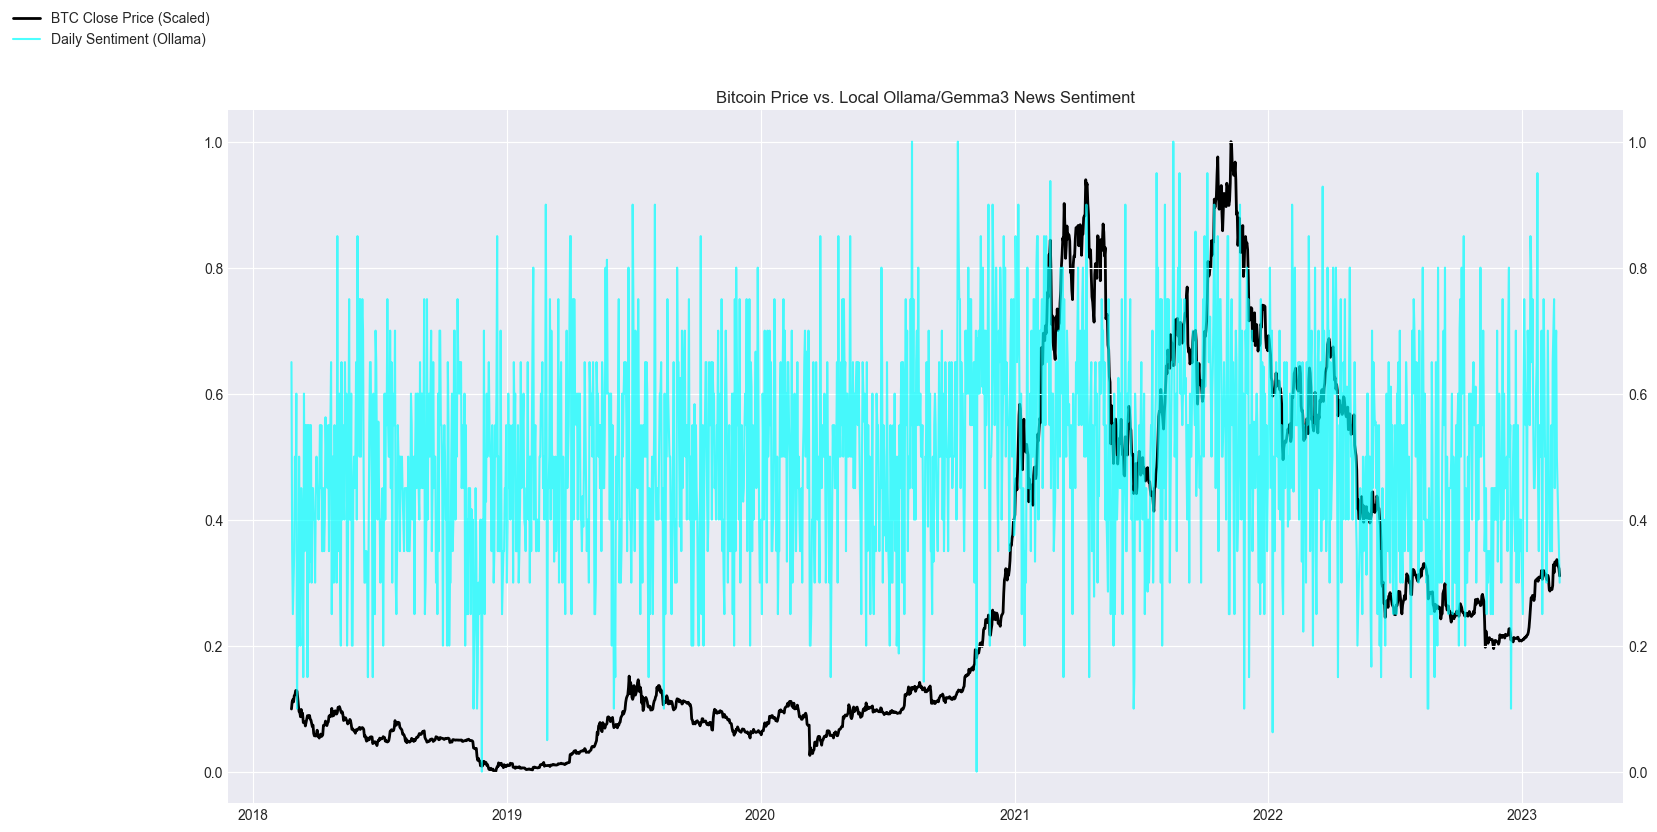


Analysis finished.


In [11]:
# %%
# ## 7. Visualize the Results
# This final cell creates the price vs. sentiment chart, saves it as a PNG file, and displays it.

print("Generating visualization...")

# Prepare data for plotting
final_df = final_df.sort_values('date').set_index('date')
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(final_df[['close_price', 'sentiment_score_ollama']].fillna(0))
scaled_df = pd.DataFrame(scaled_data, columns=['close_price', 'sentiment_score_ollama'], index=final_df.index)

# Create and save the plot
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(18, 9))
plt.plot(scaled_df.index, scaled_df['close_price'], label='BTC Close Price (Scaled)', color='black', linewidth=2)
ax2 = plt.twinx()
ax2.plot(scaled_df.index, scaled_df['sentiment_score_ollama'], label='Daily Sentiment (Ollama)', color='cyan', alpha=0.7)
plt.title('Bitcoin Price vs. Local Ollama/Gemma3 News Sentiment')
plt.gcf().legend(loc='upper left')
plot_filename = 'BTC_Price_vs_Ollama_Sentiment.png'
plt.savefig(plot_filename)
print(f"Chart saved to '{plot_filename}'")

# Display the plot
plt.show()

print("\nAnalysis finished.")